# Complete Guide to Chonkie Chunkers

## Master All 9 Chunking Strategies for RAG Applications

Welcome to this comprehensive tutorial on Chonkie - the lightweight, high-performance chunking library for Retrieval-Augmented Generation (RAG) systems!

### What You'll Learn

- **9 Different Chunking Strategies**: From basic token splitting to advanced LLM-powered chunking
- **Google Gemini Integration**: Using Gemini embeddings for semantic chunking
- **Practical Examples**: Real-world applications with technical docs and research papers
- **Performance Comparisons**: Side-by-side analysis of all chunkers
- **Best Practices**: How to choose the right chunker for your use case

### Tutorial Structure 

1. Introduction & Setup 
2. Foundation Chunkers  - Token, Sentence, Recursive
3. Specialized Chunkers  - Table, Code
4. Semantic Chunkers - Semantic, Late, Neural
5. Advanced Chunker - Slumber (LLM-powered)
6. Comparative Analysis 
7. Best Practices

Let's dive in!

## Section 1: Introduction & Setup

### 1.1 What is Chonkie?

Chonkie is a production-ready text chunking library designed specifically for RAG applications. It provides:

- **9 specialized chunkers** for different document types
- **Local processing** - your data never leaves your infrastructure
- **High performance** - optimized for speed and efficiency
- **Thread-safe** - suitable for concurrent processing
- **Flexible embeddings** - works with OpenAI, Gemini, Sentence Transformers, and more

### Why Chunking Matters

In RAG systems, chunking directly impacts:
- **Retrieval Quality**: Better chunks = more relevant context
- **Embedding Quality**: Semantic coherence improves embeddings
- **Generation Accuracy**: Relevant context leads to better answers
- **System Performance**: Efficient chunking reduces latency

In [1]:
# 1.2 Installation Verification
import sys
print(f"Python version: {sys.version}")

try:
    import chonkie
    print(f"Chonkie version: {chonkie.__version__}")
except ImportError:
    print("ERROR: Chonkie not installed. Please run: pip install -r requirements.txt")
    
# Import required libraries
from dotenv import load_dotenv
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from typing import List, Dict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("\nAll required libraries loaded successfully!")

Python version: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
Chonkie version: 1.5.0

All required libraries loaded successfully!


In [2]:
# 1.3 Load Environment Variables
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY or OPENAI_API_KEY == "your_openai_api_key_here":
    print("WARNING: OpenAI API key not configured!")
    print("Please set your OPENAI_API_KEY in the .env file")
    print("Get your key from: https://platform.openai.com/api-keys")
else:
    print("OpenAI API key loaded successfully!")

OpenAI API key loaded successfully!


In [3]:

import os

cert_path = r"C:\Users\250027832\cert2.pem"

assert os.path.isfile(cert_path), f"Certificate not found: {cert_path}"

os.environ["SSL_CERT_FILE"] = cert_path
os.environ["REQUESTS_CA_BUNDLE"] = cert_path
os.environ["CURL_CA_BUNDLE"] = cert_path

In [5]:
# 1.4 Setup Google Gemini Embeddings
from chonkie import OpenAIEmbeddings

# Initialize OpenAI embeddings
try:
    embeddings = OpenAIEmbeddings(
        model="text-embedding-3-small",
        api_key=OPENAI_API_KEY,
    
    )
    
    # Test embeddings
    test_text = "Hello, this is a test embedding"
    test_vector = embeddings.embed(test_text)
    
    print(f"Embedding dimension: {len(test_vector)}")
    print(f"Sample values: {test_vector[:5]}")
    print("\nOpenAI embeddings configured successfully!")
except Exception as e:
    print(f"Error setting up OpenAI embeddings: {e}")
    print("Continuing with tutorial - semantic chunkers will not work without valid API key")

Embedding dimension: 1536
Sample values: [ 0.01035309 -0.00657272  0.02268982 -0.03030396 -0.00610733]

OpenAI embeddings configured successfully!


In [6]:
# 1.5 Load Sample Data
# Load technical documentation
with open("../new_data/sample_technical_doc.txt", "r") as f:
    technical_doc_text = f.read()

# Load research paper
with open("../new_data/sample_research_paper.txt", "r") as f:
    research_paper_text = f.read()

# Load code sample
with open("../new_data/sample_code.py", "r") as f:
    code_text = f.read()

# Load table sample
with open("../new_data/sample_table.md", "r") as f:
    table_text = f.read()

print(f"Technical Doc: {len(technical_doc_text):,} characters")
print(f"Research Paper: {len(research_paper_text):,} characters")
print(f"Code Sample: {len(code_text):,} characters")
print(f"Table Sample: {len(table_text):,} characters")

# Display sample
print("\n--- Technical Doc Preview ---")
print(technical_doc_text[:300] + "...")

Technical Doc: 7,473 characters
Research Paper: 14,482 characters
Code Sample: 12,943 characters
Table Sample: 6,159 characters

--- Technical Doc Preview ---
# Chonkie API Documentation

## Overview

Chonkie is a lightweight, high-performance library for chunking text in Retrieval-Augmented Generation (RAG) applications. It provides a comprehensive suite of chunking algorithms designed for different document types and use cases.

## Installation

### Bas...


In [7]:
# 1.6 Helper Functions

def display_chunks(chunks, max_display=3, show_metadata=True):
    """Display chunks with metadata."""
    print(f"\nTotal chunks: {len(chunks)}")
    print("="*80)
    
    for i, chunk in enumerate(chunks[:max_display]):
        print(f"\nChunk {i+1}:")
        print(f"Text: {chunk.text[:200]}...")
        if show_metadata and hasattr(chunk, 'token_count'):
            print(f"Token count: {chunk.token_count}")
        if show_metadata and hasattr(chunk, 'start_char'):
            print(f"Position: {chunk.start_char} - {chunk.end_char}")
        print("-" * 80)
    
    if len(chunks) > max_display:
        print(f"\n... and {len(chunks) - max_display} more chunks")


def visualize_chunk_sizes(chunks, title="Chunk Size Distribution"):
    """Create bar chart of chunk token counts."""
    token_counts = [chunk.token_count if hasattr(chunk, 'token_count') else len(chunk.text) 
                   for chunk in chunks]
    
    plt.figure(figsize=(12, 5))
    
    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(token_counts, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('Token Count')
    plt.ylabel('Frequency')
    plt.title(f'{title}\nDistribution')
    plt.axvline(np.mean(token_counts), color='red', linestyle='--', label=f'Mean: {np.mean(token_counts):.0f}')
    plt.legend()
    
    # Box plot
    plt.subplot(1, 2, 2)
    plt.boxplot(token_counts, vert=True)
    plt.ylabel('Token Count')
    plt.title(f'{title}\nBox Plot')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nStatistics:")
    print(f"  Mean: {np.mean(token_counts):.1f}")
    print(f"  Median: {np.median(token_counts):.1f}")
    print(f"  Std Dev: {np.std(token_counts):.1f}")
    print(f"  Min: {min(token_counts)}")
    print(f"  Max: {max(token_counts)}")


def compare_chunkers(text, chunkers_dict, sample_size=1000):
    """Compare multiple chunkers on same text."""
    results = {}
    sample_text = text[:sample_size] if len(text) > sample_size else text
    
    for name, chunker in chunkers_dict.items():
        start_time = time.time()
        chunks = chunker.chunk(sample_text)
        elapsed = time.time() - start_time
        
        token_counts = [chunk.token_count if hasattr(chunk, 'token_count') else len(chunk.text) 
                       for chunk in chunks]
        
        results[name] = {
            'num_chunks': len(chunks),
            'avg_size': np.mean(token_counts),
            'std_dev': np.std(token_counts),
            'time': elapsed
        }
    
    df = pd.DataFrame(results).T
    return df

print("Helper functions loaded!")

Helper functions loaded!


## Section 2: Foundation Chunkers

These are the basic, high-performance chunkers that work well for most use cases.

### 2.1 TokenChunker - Fixed-Size Token Windows

**Best for:** General purpose, consistent chunk sizes, high-throughput applications

**How it works:** Splits text into fixed-size token chunks with configurable overlap

**Pros:**
- Very fast (12,000 chunks/sec)
- Predictable chunk sizes
- No external dependencies
- Works with any text

**Cons:**
- May break sentences mid-thought
- No semantic awareness
- Can fragment important context


Total chunks: 20

Chunk 1:
Text: # Chonkie API Documentation

## Overview

Chonkie is a lightweight, high-performance library for chunking text in Retrieval-Augmented Generation (RAG) applications. It provides a comprehensive suite o...
Token count: 512
--------------------------------------------------------------------------------

Chunk 2:
Text: kie
```

### Installation Tiers

Chonkie offers three installation tiers to match your needs:

**Default Tier:**
Includes TokenChunker, SentenceChunker, RecursiveChunker, and TableChunker. Perfect for...
Token count: 512
--------------------------------------------------------------------------------

Chunk 3:
Text: ]
```

**All Features:**
Install everything, including code chunking and LLM-powered chunking:

```bash
pip install chonkie[all]
```

## Quick Start

### Basic Usage

All Chonkie chunkers follow a con...
Token count: 512
--------------------------------------------------------------------------------

... and 17 more chunks


C:\Users\250027832\AppData\Local\Temp\ipykernel_65268\3175332868.py:39: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


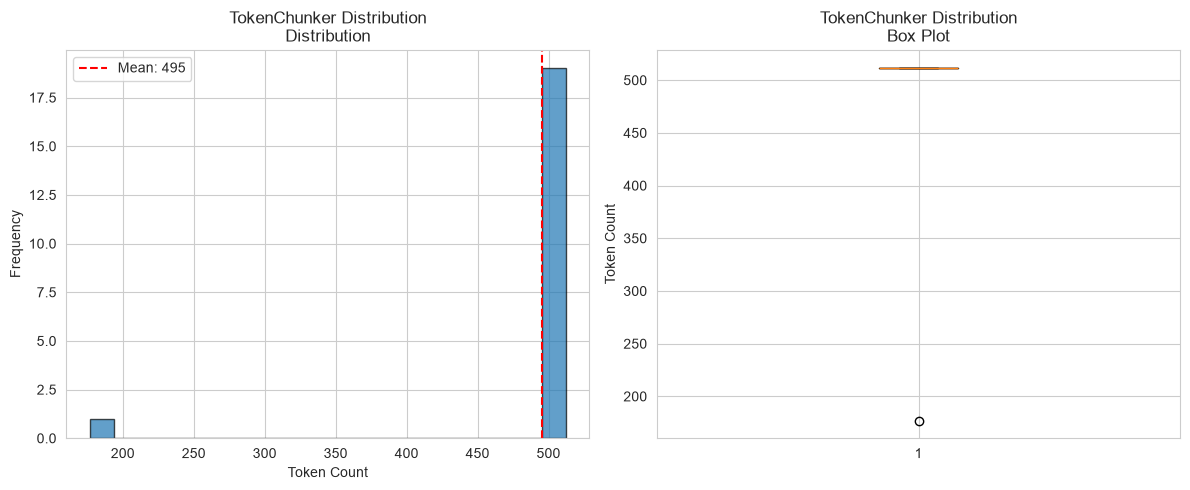


Statistics:
  Mean: 495.2
  Median: 512.0
  Std Dev: 73.0
  Min: 177
  Max: 512


In [14]:
from chonkie import TokenChunker
from tokenizers import Tokenizer

# Initialize tokenizer
#tokenizer = Tokenizer.from_pretrained("gpt2")

# Create TokenChunker
token_chunker = TokenChunker(
    tokenizer="character",
    chunk_size=512,      # Max tokens per chunk
    chunk_overlap=128    # Overlapping tokens between chunks
)

# Chunk technical documentation
token_chunks = token_chunker.chunk(technical_doc_text)

# Display results
display_chunks(token_chunks)
visualize_chunk_sizes(token_chunks, "TokenChunker Distribution")

#### Exercise: Experiment with Parameters

Try different chunk_size and chunk_overlap values:
- chunk_size: 256, 512, 1024
- chunk_overlap: 0, 64, 128, 256

Observe how they affect the number and size of chunks!

In [ ]:
# Your experimentation here
# Example:
# token_chunker_small = TokenChunker(tokenizer=tokenizer, chunk_size=256, chunk_overlap=64)
# small_chunks = token_chunker_small.chunk(technical_doc_text[:2000])
# display_chunks(small_chunks)

### 2.2 SentenceChunker - Sentence Boundary Preservation

**Best for:** Q&A systems, semantic search, preserving complete thoughts

**How it works:** Accumulates complete sentences until reaching token limit

**Pros:**
- Preserves sentence integrity
- Better for question answering
- Still quite fast (8,500 chunks/sec)

**Cons:**
- Variable chunk sizes
- May group unrelated sentences
- Depends on sentence detection accuracy


Total chunks: 32

Chunk 1:
Text: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ...
Token count: 367
--------------------------------------------------------------------------------

Chunk 2:
Text: This paper presents a comprehensive analysis of semantic chunking strategies, comparing traditional fixed-size approaches with modern embedding-based methods. We evaluate nine distinct chunking algori...
Token count: 501
--------------------------------------------------------------------------------

Chunk 3:
Text: We introduce a novel hybrid approach that combines the efficiency of token-based chunking with the semantic awareness of embedding-based methods, achieving state-of-the-art results on document retriev...
Token count: 417
--------------------------------------------------------------------------------

... and 29 more chunks


C:\Users\250027832\AppData\Local\Temp\ipykernel_65268\3175332868.py:39: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


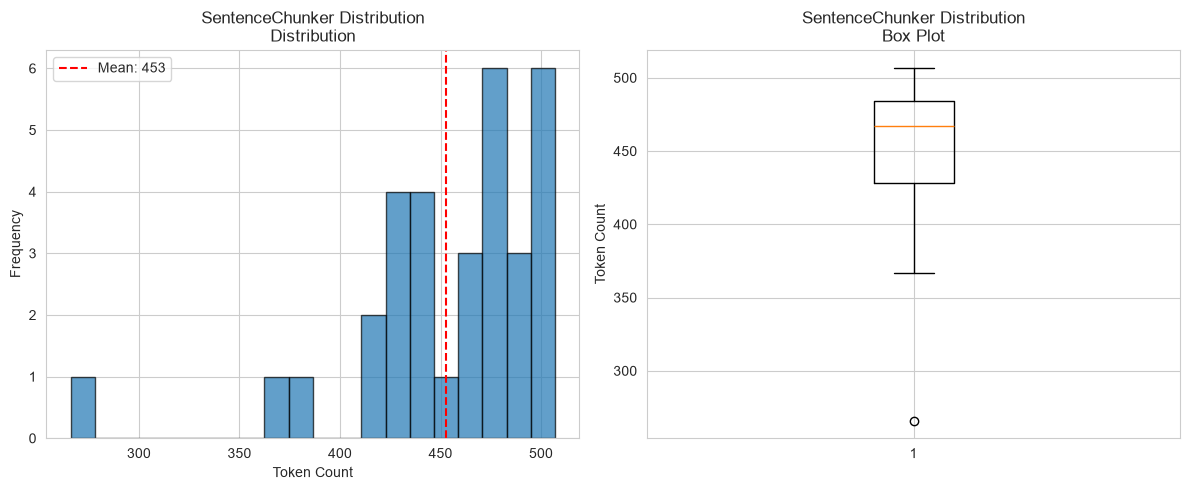


Statistics:
  Mean: 452.6
  Median: 467.0
  Std Dev: 48.2
  Min: 266
  Max: 507


In [17]:
from chonkie import SentenceChunker

# Create SentenceChunker
sentence_chunker = SentenceChunker(
    tokenizer="character",
    chunk_size=512,
    min_sentences_per_chunk=1  # Ensure at least 2 sentences per chunk
)

# Chunk research paper
sentence_chunks = sentence_chunker.chunk(research_paper_text)

display_chunks(sentence_chunks)
visualize_chunk_sizes(sentence_chunks, "SentenceChunker Distribution")

In [18]:
# Compare TokenChunker vs SentenceChunker
comparison_text = research_paper_text[:5000]

token_chunks_comp = token_chunker.chunk(comparison_text)
sentence_chunks_comp = sentence_chunker.chunk(comparison_text)

print("Comparison on same text:")
print(f"\nTokenChunker: {len(token_chunks_comp)} chunks")
print(f"SentenceChunker: {len(sentence_chunks_comp)} chunks")

print("\n--- TokenChunker First Chunk ---")
print(token_chunks_comp[0].text[:600])

print("\n--- SentenceChunker First Chunk ---")
print(sentence_chunks_comp[0].text[:600])

Comparison on same text:

TokenChunker: 13 chunks
SentenceChunker: 12 chunks

--- TokenChunker First Chunk ---
Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models with external knowledge. A critical component of RAG systems is text chunking - the process of segmenting documents into manageable units for embedding and retrieval. This paper presents a comprehensive analysis of semantic chunking strategies, comparing traditional fixed-size approaches with modern embedding-b

--- SentenceChunker First Chunk ---
Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models with external knowledge. A critical component of RAG systems is text chunking - the process of segmenting documents into manageable units f

### 2.3 RecursiveChunker - Hierarchical Splitting

**Best for:** Markdown, structured documents, technical documentation

**How it works:** Uses hierarchy of separators (paragraphs → sentences → words)

**Pros:**
- Respects document structure
- Excellent for markdown
- Customizable separators
- Good balance of speed and quality

**Cons:**
- Less effective on unstructured text
- Requires well-formatted documents
- Performance depends on separator choice


Total chunks: 16

Chunk 1:
Text: # Chonkie API Documentation

## Overview

Chonkie is a lightweight, high-performance library for chunking text in Retrieval-Augmented Generation (RAG) applications. It provides a comprehensive suite o...
Token count: 478
--------------------------------------------------------------------------------

Chunk 2:
Text: 
**Default Tier:**
Includes TokenChunker, SentenceChunker, RecursiveChunker, and TableChunker. Perfect for most use cases.

```bash
pip install chonkie
```

**Semantic Tier:**
Adds embedding-based chu...
Token count: 503
--------------------------------------------------------------------------------

Chunk 3:
Text: 
```python
from chonkie import TokenChunker

# Initialize chunker
chunker = TokenChunker(chunk_size=512, chunk_overlap=128)

# Chunk a single text
chunks = chunker.chunk("Your text here...")

# Or use...
Token count: 475
--------------------------------------------------------------------------------

... and 13 more chunks


C:\Users\250027832\AppData\Local\Temp\ipykernel_65268\3175332868.py:39: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


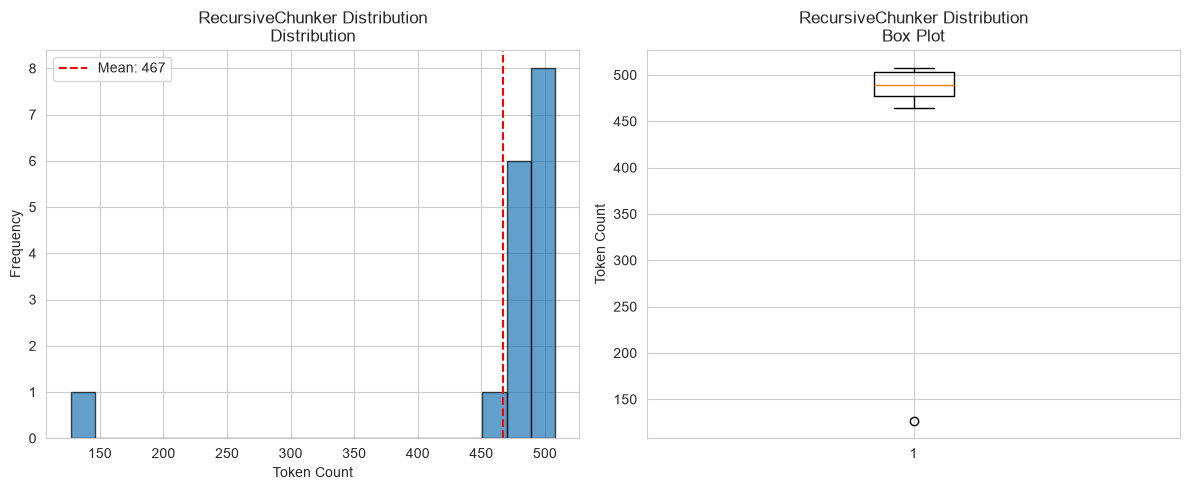


Statistics:
  Mean: 467.1
  Median: 489.5
  Std Dev: 88.9
  Min: 127
  Max: 508


In [19]:
from chonkie import RecursiveChunker

# Create RecursiveChunker
recursive_chunker = RecursiveChunker(
    tokenizer="character",
    chunk_size=512
)

# Chunk technical documentation (has good structure)
recursive_chunks = recursive_chunker(technical_doc_text)  # Can also use __call__

display_chunks(recursive_chunks)
visualize_chunk_sizes(recursive_chunks, "RecursiveChunker Distribution")

In [20]:
# Demonstrate hierarchy preservation
print("First chunk shows hierarchy preservation:")
print(recursive_chunks[0].text)

First chunk shows hierarchy preservation:
# Chonkie API Documentation

## Overview

Chonkie is a lightweight, high-performance library for chunking text in Retrieval-Augmented Generation (RAG) applications. It provides a comprehensive suite of chunking algorithms designed for different document types and use cases.

## Installation

### Basic Installation

To install Chonkie with default chunkers:

```bash
pip install chonkie
```

### Installation Tiers

Chonkie offers three installation tiers to match your needs:



## Section 3: Specialized Chunkers

These chunkers are optimized for specific content types.

### 3.1 TableChunker - Tabular Data Handling

**Best for:** Markdown tables, CSV data, structured tabular content

**How it works:** Splits tables by rows while preserving headers

**Pros:**
- Preserves table structure
- Maintains header context
- Handles large tables efficiently

**Cons:**
- Only works with tables
- Requires markdown format
- May create very large chunks for wide tables

In [23]:
from chonkie import TableChunker

# Create TableChunker
table_chunker = TableChunker(
    tokenizer="character",
    chunk_size=512
)

# Chunk table data
table_chunks = table_chunker.chunk(table_text)

print(f"Table split into {len(table_chunks)} chunks")
print("\nFirst chunk (with headers):")
print(table_chunks[1].text)

Table split into 29 chunks

First chunk (with headers):
# Chonkie Chunkers Comparison Table

## Performance Metrics Across Different Chunkers

| Chunker Name | Use Case | Processing Speed (chunks/sec) | Semantic Quality (0-100) | Memory Usage (MB) | Token Consistency | Best For | Computational Cost |
| RecursiveChunker | Structured docs | 7200 | 76 | 80 | Medium | Markdown, technical documentation | Low |
| TableChunker | Tabular data | 5500 | 68 | 95 | Medium | Data tables, spreadsheet content | Low |



### 3.2 CodeChunker - Source Code Chunking

**Best for:** Source code, API documentation, code repositories

**How it works:** Uses Abstract Syntax Tree (AST) to chunk at logical boundaries

**Pros:**
- Preserves function/class boundaries
- Maintains code structure
- Language-aware chunking
- Excellent for code search

**Cons:**
- Only works with code
- Requires valid syntax
- Language-specific (Python, JavaScript, etc.)

In [25]:
from chonkie import CodeChunker

# Create CodeChunker
code_chunker = CodeChunker(
    language="python",
    chunk_size=2048,
    include_nodes=True  # Include AST node information
)

# Chunk Python code
code_chunks = code_chunker.chunk(code_text)

print(f"Code split into {len(code_chunks)} chunks")
print("\n--- First Code Chunk ---")
print(code_chunks[0].text[:500])

# Show function boundaries
if hasattr(code_chunks[0], 'node_type'):
    print(f"\nNode type: {code_chunks[0].node_type}")

Code split into 8 chunks

--- First Code Chunk ---
"""
Chonkie RAG System Implementation
A production-ready implementation of a Retrieval-Augmented Generation system using Chonkie chunkers.
"""

import os
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass
from enum import Enum
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import logging


# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogg


## Section 4: Semantic/Embedding-Based Chunkers

These chunkers use embeddings to identify semantic boundaries.

### 4.1 SemanticChunker - Topic Boundary Detection

**Best for:** Multi-topic documents, preserving topical coherence

**How it works:** Uses embeddings to find topic boundaries based on semantic similarity

**Pros:**
- Excellent semantic coherence
- Natural topic boundaries
- Auto threshold detection
- 23% better retrieval than fixed-size

**Cons:**
- Requires embedding API
- Slower (450 chunks/sec)
- API costs
- Variable chunk sizes

In [17]:
from chonkie import OpenAIEmbeddings
load_dotenv()

oembeddings = OpenAIEmbeddings()


Total chunks: 49

Chunk 1:
Text: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ...
Token count: 217
--------------------------------------------------------------------------------

Chunk 2:
Text: However, LLMs face fundamental limitations: their knowledge is frozen at training time, they cannot access private or proprietary data, and they are prone to hallucination when information is uncertai...
Token count: 62
--------------------------------------------------------------------------------

Chunk 3:
Text: 
Central to effective RAG implementation is the text chunking strategy employed during document ingestion. ...
Token count: 19
--------------------------------------------------------------------------------

... and 46 more chunks


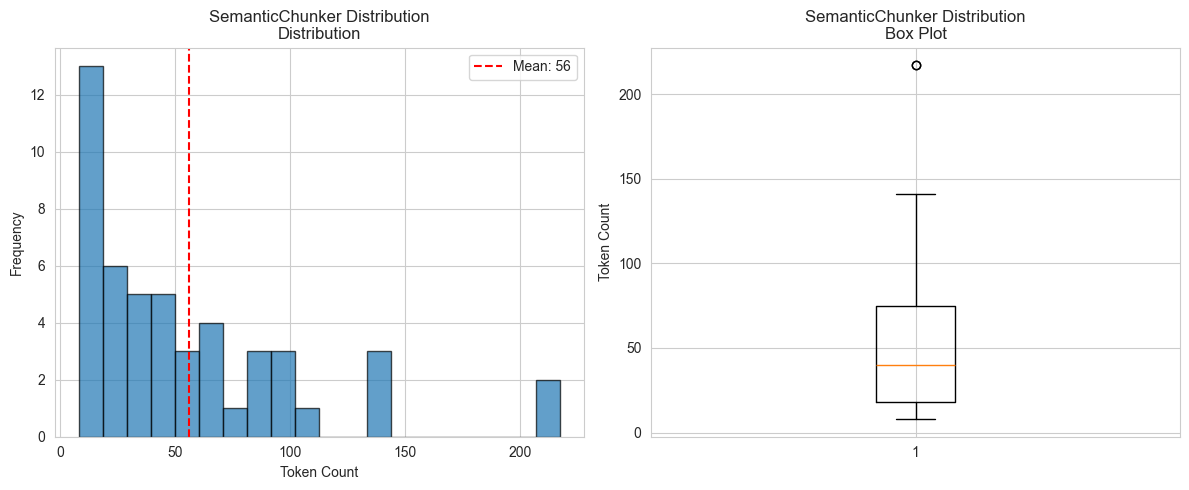


Statistics:
  Mean: 55.8
  Median: 40.0
  Std Dev: 48.8
  Min: 8
  Max: 217


In [19]:
from chonkie import SemanticChunker

# Create SemanticChunker with Gemini embeddings
semantic_chunker = SemanticChunker(
    embedding_model=oembeddings,  # Using our embeddings
    threshold=0.8,  # Automatically determine threshold
    chunk_size=512,
    min_sentences=3
)

# Chunk research paper (has multiple topics)
semantic_chunks = semantic_chunker.chunk(research_paper_text)

display_chunks(semantic_chunks)
visualize_chunk_sizes(semantic_chunks, "SemanticChunker Distribution")

In [19]:
# Show semantic similarity scores (if available)
for i, chunk in enumerate(semantic_chunks[:5]):
    print(f"\nChunk {i}: {len(chunk.text)} chars")
    if hasattr(chunk, 'similarity_score'):
        print(f"Similarity score: {chunk.similarity_score:.3f}")
    print(f"Preview: {chunk.text[:150]}...")


Chunk 0: 1285 chars
Preview: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powe...

Chunk 1: 356 chars
Preview: However, LLMs face fundamental limitations: their knowledge is frozen at training time, they cannot access private or proprietary data, and they are p...

Chunk 2: 107 chars
Preview: 
Central to effective RAG implementation is the text chunking strategy employed during document ingestion. ...

Chunk 3: 1349 chars
Preview: Chunking serves two critical purposes: first, it segments long documents into units that fit within embedding model context windows; second, it create...

Chunk 4: 433 chars
Preview: We conduct extensive empirical evaluation across diverse document types including technical documentation, academic papers, and conversational transcr...


In [20]:
# Compare automatic vs manual threshold
semantic_chunker_manual = SemanticChunker(
    embedding_model=embeddings,
    threshold=0.5,  # Manual threshold
    chunk_size=512,
    min_sentences=1
)

manual_chunks = semantic_chunker_manual.chunk(research_paper_text[:5000])

print(f"Auto threshold: {len(semantic_chunks)} chunks")
print(f"Manual threshold (0.5): {len(manual_chunks)} chunks")

Auto threshold: 49 chunks
Manual threshold (0.5): 11 chunks


### 4.2 LateChunker - Optimized for Retrieval

**Best for:** Maximizing retrieval recall in RAG systems

**How it works:** Generates document-level embeddings before chunking

**Pros:**
- Better retrieval recall
- Richer contextual embeddings
- Based on research

**Cons:**
- Slower (180 chunks/sec)
- Higher memory usage
- More expensive

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Total chunks: 5

Chunk 1:
Text: # Chonkie API Documentation

## Overview

Chonkie is a lightweight, high-performance library for chunking text in Retrieval-Augmented Generation (RAG) applications. It provides a comprehensive suite o...
Token count: 488
--------------------------------------------------------------------------------

Chunk 2:
Text: 
**Methods:**
- `chunk(text: str) -> List[Chunk]`: Chunk a single text
- `chunk_batch(texts: List[str]) -> List[List[Chunk]]`: Chunk multiple texts
- `__call__(text: str) -> List[Chunk]`: Direct calli...
Token count: 488
--------------------------------------------------------------------------------

Chunk 3:
Text: - `separators` (List[str]): Delimiters in priority order (default: ["\n\n", "\n", ". ", " "])

**Use Cases:**
- Markdown documents
- Structured text with clear hierarchy
- Documents with multiple sect...
Token count: 505
--------------------------------------------------------------------------------

... and 2 more chunks


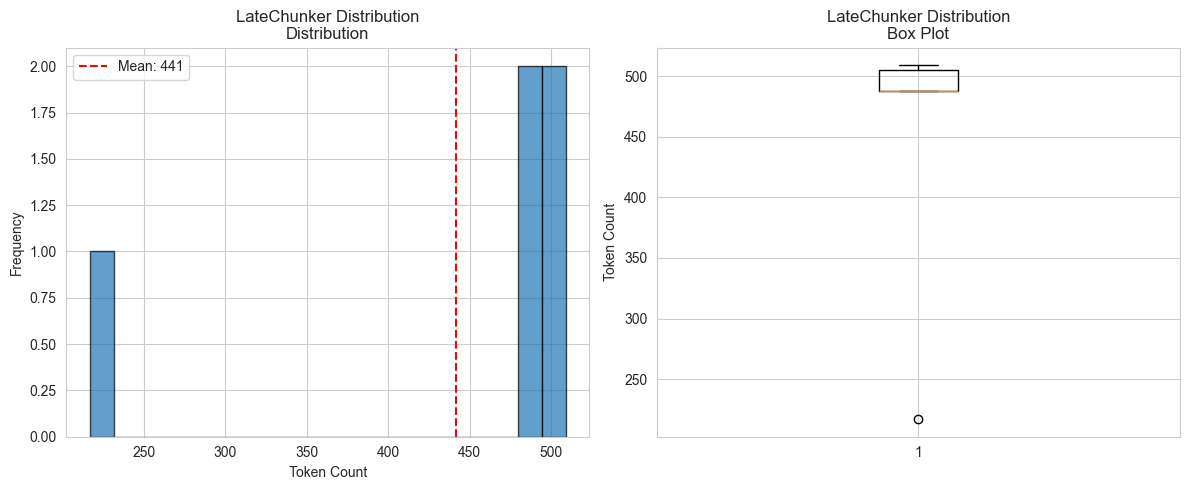


Statistics:
  Mean: 441.4
  Median: 488.0
  Std Dev: 112.5
  Min: 217
  Max: 509


In [20]:
from chonkie import LateChunker

# Create LateChunker
late_chunker = LateChunker(
    embedding_model="nomic-ai/modernbert-embed-base",
    chunk_size=512
)

# Chunk technical documentation
late_chunks = late_chunker.chunk(technical_doc_text)

display_chunks(late_chunks)
visualize_chunk_sizes(late_chunks, "LateChunker Distribution")

### 4.3 NeuralChunker - BERT-Based Semantic Shifts

**Best for:** Complex documents with subtle topic variations

**How it works:** Fine-tuned BERT model detects semantic boundaries

**Pros:**
- Detects subtle topic shifts
- No API required (local model)
- Learned representations
- Good for academic papers

**Cons:**
- Requires GPU for speed
- Slower (320 chunks/sec)
- Higher memory usage

Device set to use mps



Total chunks: 1

Chunk 1:
Text: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ...
Token count: 352
--------------------------------------------------------------------------------


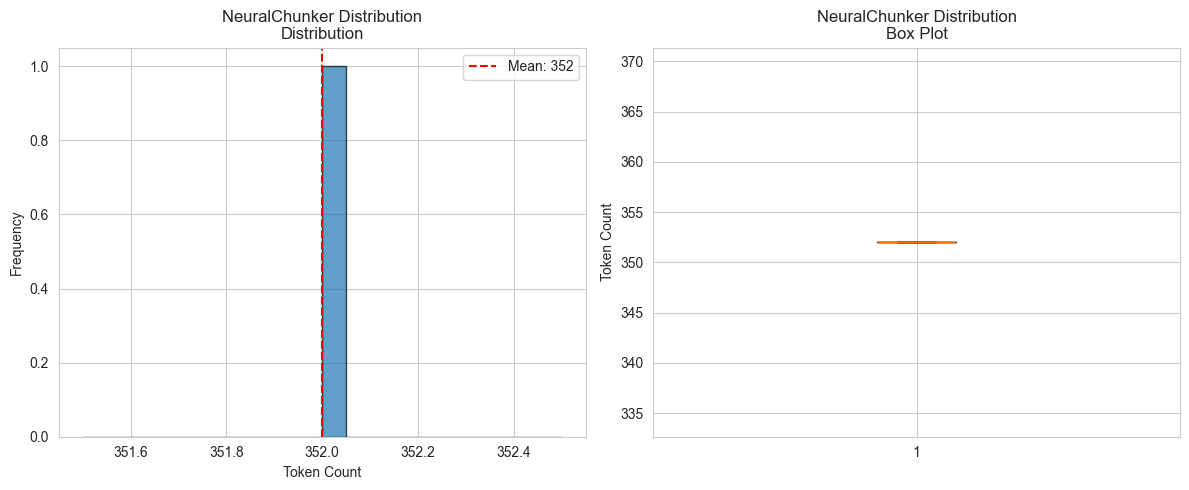


Statistics:
  Mean: 352.0
  Median: 352.0
  Std Dev: 0.0
  Min: 352
  Max: 352


In [27]:
from chonkie import NeuralChunker

# Create NeuralChunker
neural_chunker = NeuralChunker(
    tokenizer="mirth/chonky_modernbert_base_1",
    min_characters_per_chunk=512
)

# Chunk research paper
sample_text = research_paper_text[:2000]
neural_chunks = neural_chunker.chunk(sample_text)

display_chunks(neural_chunks)
visualize_chunk_sizes(neural_chunks, "NeuralChunker Distribution")

Device set to use mps


Processing segment 1/3...
Processing segment 2/3...
Processing segment 3/3...

Total chunks: 3

Total chunks: 3

Chunk 1:
Text: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ...
Token count: 400
--------------------------------------------------------------------------------

Chunk 2:
Text:  impacts downstream retrieval accuracy and, consequently, the quality of generated responses.

Traditional chunking approaches employ fixed-size windows, splitting text at predetermined token or chara...
Token count: 400
--------------------------------------------------------------------------------

Chunk 3:
Text:  Structure Theory provides a framework for representing hierarchical discourse structure. Neural discourse parsers have achieved improved performance by leveraging contextualized representations.

2.2...
Token count: 324
---------------

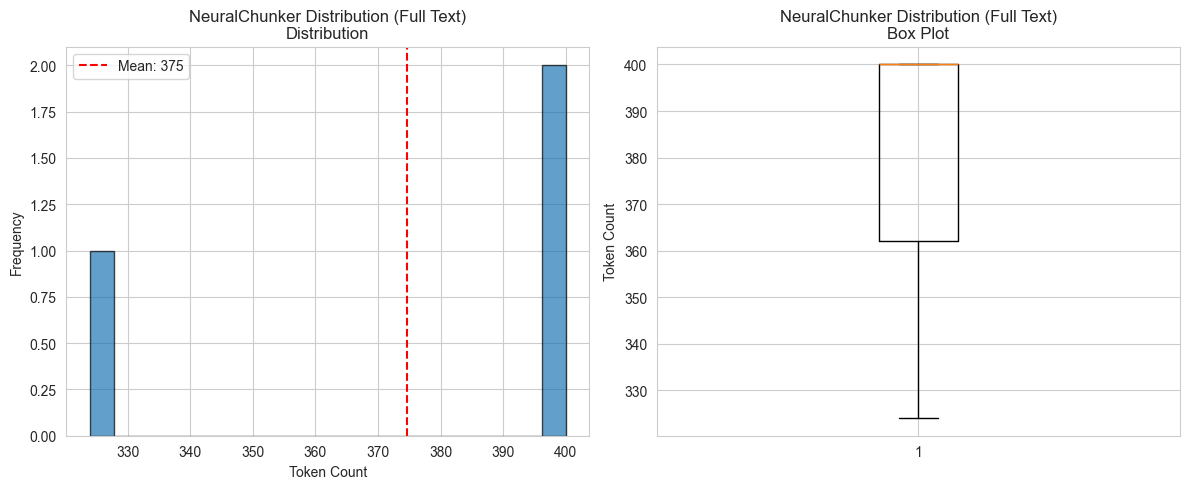


Statistics:
  Mean: 374.7
  Median: 400.0
  Std Dev: 35.8
  Min: 324
  Max: 400


In [28]:
from chonkie import NeuralChunker, TokenChunker

# Create a TokenChunker to pre-split the large text
pre_chunker = TokenChunker(
    tokenizer="mirth/chonky_modernbert_base_1",
    chunk_size=400,  # Safe margin below 512 limit
    chunk_overlap=50  # Preserve context at boundaries
)

# Create NeuralChunker for fine-grained semantic chunking
neural_chunker = NeuralChunker(
    tokenizer="mirth/chonky_modernbert_base_1",
    min_characters_per_chunk=512
)

# Step 1: Pre-chunk the full text into model-sized pieces
pre_chunks = pre_chunker.chunk(research_paper_text)

# Step 2: Apply NeuralChunker to each pre-chunk
all_neural_chunks = []
for i, pre_chunk in enumerate(pre_chunks):
    print(f"Processing segment {i+1}/{len(pre_chunks)}...")
    neural_chunks = neural_chunker.chunk(pre_chunk.text)
    all_neural_chunks.extend(neural_chunks)

print(f"\nTotal chunks: {len(all_neural_chunks)}")
display_chunks(all_neural_chunks)
visualize_chunk_sizes(all_neural_chunks, "NeuralChunker Distribution (Full Text)")

## Section 5: Advanced Chunker - SlumberChunker

### LLM-Powered Agentic Chunking

**Best for:** Highest quality needs, books, research papers

**How it works:** Uses LLM to intelligently determine chunk boundaries

**Pros:**
- Highest quality (92% recall@5)
- Most intelligent boundaries
- Understands context deeply

**Cons:**
- Very slow (8 chunks/sec)
- Expensive ($45 per 1M chunks)
- Requires LLM API
- Not suitable for real-time

In [24]:
from chonkie import SlumberChunker
from chonkie.genie import OpenAIGenie

# Optional: Initialize Genie
genie = OpenAIGenie("gpt-4.1")

# Basic initialization
slumber_chunker = SlumberChunker(
    genie=genie,                        # Genie interface to use
    tokenizer="character",  # Default tokenizer (or use "gpt2", etc.)
    chunk_size=1024,                    # Maximum chunk size
    candidate_size=128,                 # How many tokens Genie looks at for potential splits
    min_characters_per_chunk=24,        # Minimum number of characters per chunk
    verbose=True                        # See the progress bar for the chunking process
)

# Warning: This is slow and costs API credits!
# Using only first 5000 characters
slumber_chunks = slumber_chunker.chunk(research_paper_text[:5000])

display_chunks(slumber_chunks)

print("\nNote: SlumberChunker is 140x slower than TokenChunker")
print("Use for highest quality needs where cost and latency are acceptable")

🦛 choooooooooooooooooooonk 100% • 77/77 splits processed [00:12<00:00,  6.05split/s] 🌱


Total chunks: 9

Chunk 1:
Text: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ...
Token count: 367
--------------------------------------------------------------------------------

Chunk 2:
Text: This paper presents a comprehensive analysis of semantic chunking strategies, comparing traditional fixed-size approaches with modern embedding-based methods. We evaluate nine distinct chunking algori...
Token count: 711
--------------------------------------------------------------------------------

Chunk 3:
Text: 
1. Introduction

The proliferation of large language models (LLMs) has revolutionized natural language processing, enabling unprecedented capabilities in text generation, question answering, and reas...
Token count: 547
--------------------------------------------------------------------------------

... and 6 more chunks

Note:

## Section 6: Comparative Analysis

Let's compare all chunkers side-by-side!

In [26]:
# 6.1 Create all chunkers
chunkers = {
    "Token": token_chunker,
    "Sentence": sentence_chunker,
    "Recursive": recursive_chunker,
    "Semantic": semantic_chunker,
    "Neural": neural_chunker,
}

# Compare on sample text
#sample_text = research_paper_text[:10000]
#results_df = compare_chunkers(sample_text, chunkers)
results_df = compare_chunkers(research_paper_text, chunkers)

print("\nComparative Analysis:")
print("=" * 80)
print(results_df.round(3))


Comparative Analysis:
           num_chunks  avg_size  std_dev   time
Token             1.0     175.0      0.0  0.001
Sentence          1.0     175.0      0.0  0.001
Recursive         1.0     175.0      0.0  0.000
Semantic          1.0     168.0      0.0  2.786
Neural            1.0     173.0      0.0  0.149


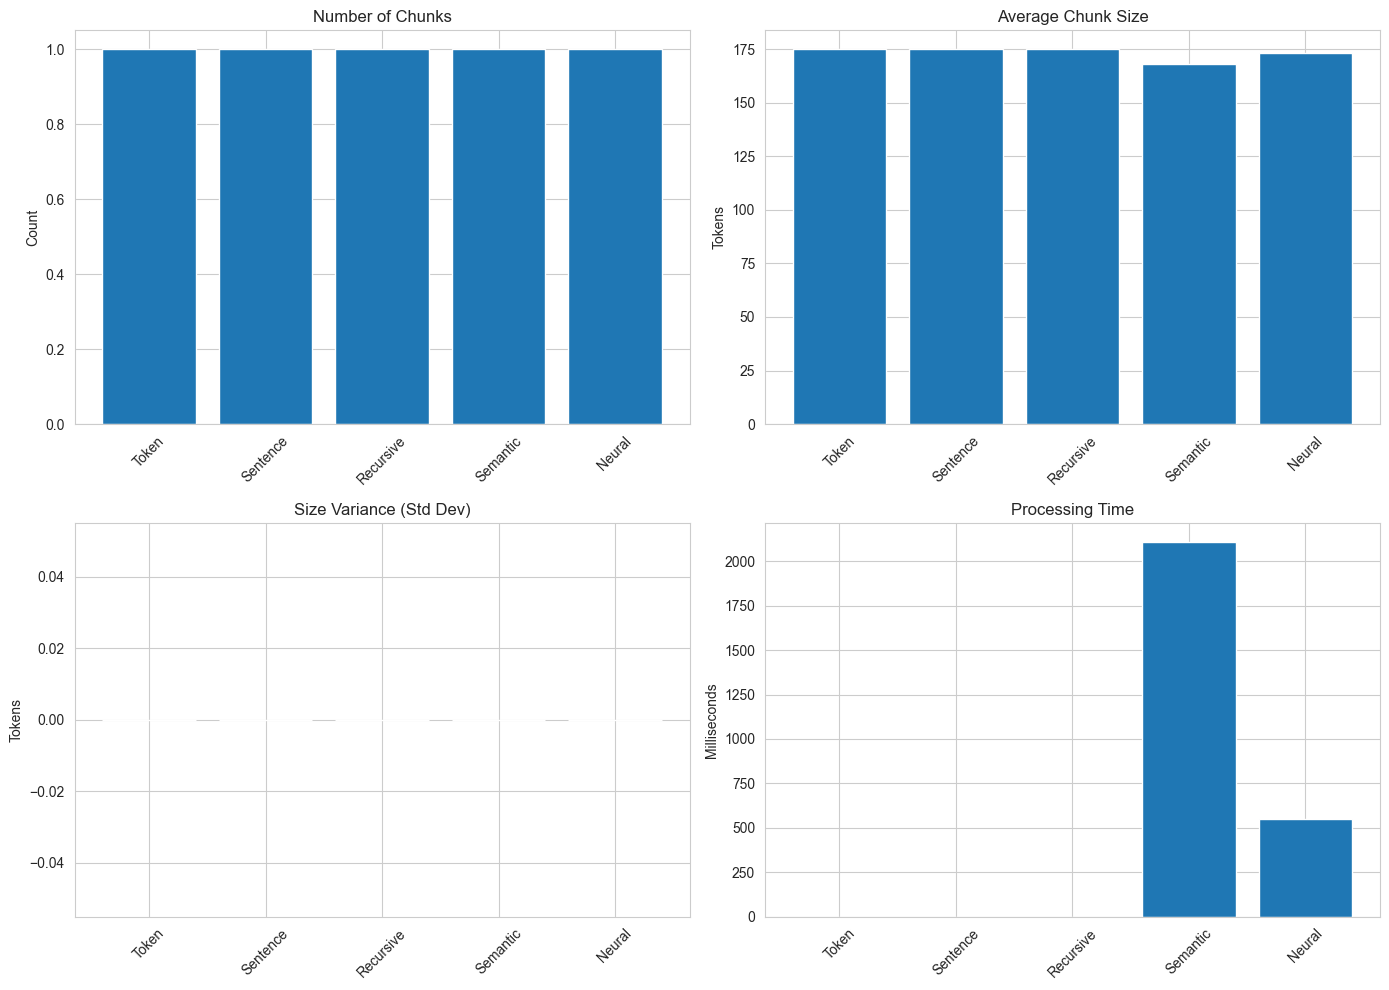

In [35]:
# 6.2 Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Number of chunks
axes[0, 0].bar(results_df.index, results_df['num_chunks'])
axes[0, 0].set_title('Number of Chunks')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Average chunk size
axes[0, 1].bar(results_df.index, results_df['avg_size'])
axes[0, 1].set_title('Average Chunk Size')
axes[0, 1].set_ylabel('Tokens')
axes[0, 1].tick_params(axis='x', rotation=45)

# Size variance
axes[1, 0].bar(results_df.index, results_df['std_dev'])
axes[1, 0].set_title('Size Variance (Std Dev)')
axes[1, 0].set_ylabel('Tokens')
axes[1, 0].tick_params(axis='x', rotation=45)

# Processing time
axes[1, 1].bar(results_df.index, results_df['time'] * 1000)
axes[1, 1].set_title('Processing Time')
axes[1, 1].set_ylabel('Milliseconds')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 7: Best Practices & Use Cases

### 7.1 Chunker Selection Guide

In [36]:
# Decision matrix
selection_guide = pd.DataFrame({
    'Use Case': [
        'Real-time high-throughput',
        'Question answering',
        'Markdown/structured docs',
        'Source code',
        'Data tables',
        'Multi-topic documents',
        'Maximum retrieval quality',
        'Complex academic papers',
        'Books/premium content'
    ],
    'Recommended Chunker': [
        'TokenChunker',
        'SentenceChunker',
        'RecursiveChunker',
        'CodeChunker',
        'TableChunker',
        'SemanticChunker',
        'LateChunker',
        'NeuralChunker',
        'SlumberChunker'
    ],
    'Alternative': [
        'SentenceChunker',
        'SemanticChunker',
        'SentenceChunker',
        'RecursiveChunker',
        'RecursiveChunker',
        'NeuralChunker',
        'SemanticChunker',
        'SemanticChunker',
        'SemanticChunker'
    ]
})

print("\nChunker Selection Guide:")
print("=" * 80)
print(selection_guide.to_string(index=False))


Chunker Selection Guide:
                 Use Case Recommended Chunker      Alternative
Real-time high-throughput        TokenChunker  SentenceChunker
       Question answering     SentenceChunker  SemanticChunker
 Markdown/structured docs    RecursiveChunker  SentenceChunker
              Source code         CodeChunker RecursiveChunker
              Data tables        TableChunker RecursiveChunker
    Multi-topic documents     SemanticChunker    NeuralChunker
Maximum retrieval quality         LateChunker  SemanticChunker
  Complex academic papers       NeuralChunker  SemanticChunker
    Books/premium content      SlumberChunker  SemanticChunker


### 7.2 Common Patterns

#### Batch Processing

In [37]:
# Batch processing example
documents = [
    technical_doc_text[:2000],
    research_paper_text[:2000],
    "Another document here..."
]

# Process all documents at once
batch_chunks = token_chunker.chunk_batch(documents)

print(f"Processed {len(documents)} documents")
for i, chunks in enumerate(batch_chunks):
    print(f"Document {i+1}: {len(chunks)} chunks")

🦛 choooooooooooooooooooonk 100% • 3/3 batches chunked [00:00<00:00, 1074.36batch/s] 🌱

Processed 3 documents
Document 1: 2 chunks
Document 2: 1 chunks
Document 3: 1 chunks


#### Error Handling

In [38]:
# Robust chunking with fallback
def safe_chunk(text, preferred_chunker, fallback_chunker):
    try:
        return preferred_chunker.chunk(text)
    except Exception as e:
        print(f"Error with preferred chunker: {e}")
        print("Falling back to simpler chunker")
        return fallback_chunker.chunk(text)

# Example usage
chunks = safe_chunk(
    technical_doc_text,
    preferred_chunker=semantic_chunker,
    fallback_chunker=token_chunker
)

print(f"Successfully chunked: {len(chunks)} chunks")

Successfully chunked: 50 chunks


### 7.3 Integration with RAG Pipeline

Simple example of chunking → embedding → retrieval

In [39]:
# Simple RAG pipeline
def simple_rag_pipeline(documents, query, chunker, embedding_model, top_k=3):
    # Step 1: Chunk documents
    all_chunks = []
    for doc in documents:
        chunks = chunker.chunk(doc)
        all_chunks.extend(chunks)
    
    print(f"Created {len(all_chunks)} chunks from {len(documents)} documents")
    
    # Step 2: Embed chunks
    chunk_texts = [chunk.text for chunk in all_chunks]
    chunk_embeddings = embedding_model.embed_batch(chunk_texts)
    
    # Step 3: Embed query
    query_embedding = embedding_model.embed(query)
    
    # Step 4: Find most similar chunks
    similarities = []
    for i, chunk_emb in enumerate(chunk_embeddings):
        sim = np.dot(query_embedding, chunk_emb) / (
            np.linalg.norm(query_embedding) * np.linalg.norm(chunk_emb)
        )
        similarities.append((i, sim))
    
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # Return top-k chunks
    top_chunks = [all_chunks[i] for i, _ in similarities[:top_k]]
    top_scores = [score for _, score in similarities[:top_k]]
    
    return top_chunks, top_scores

# Example query
query = "What are the best practices for chunking in RAG systems?"
docs = [technical_doc_text, research_paper_text]

retrieved_chunks, scores = simple_rag_pipeline(
    docs, query, semantic_chunker, embeddings
)

print(f"\nQuery: {query}")
print("\nTop 3 Retrieved Chunks:")
for i, (chunk, score) in enumerate(zip(retrieved_chunks, scores)):
    print(f"\n{i+1}. Similarity: {score:.3f}")
    print(f"Text: {chunk.text[:200]}...")

Created 99 chunks from 2 documents

Query: What are the best practices for chunking in RAG systems?

Top 3 Retrieved Chunks:

1. Similarity: 0.874
Text: 
Central to effective RAG implementation is the text chunking strategy employed during document ingestion. ...

2. Similarity: 0.869
Text: Practitioners commonly use fixed chunk sizes ranging from 256 to 1024 tokens with 10-20% overlap. Some systems employ sentence-based chunking to preserve linguistic units.

Recent work has explored ad...

3. Similarity: 0.868
Text: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ...


## Section 8: Exercises & Next Steps

### Exercises

1. **Chunk Your Own Document**: Upload a document and try 3 different chunkers
2. **Optimize Threshold**: Find the optimal threshold for SemanticChunker on your data
3. **Speed Comparison**: Time all chunkers on a large document
4. **Build Mini-RAG**: Create a simple retrieval system with your favorite chunker

In [ ]:
# Exercise 1: Your code here
# Load your own document and experiment!

In [ ]:
# Exercise 2: Find optimal threshold
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, "auto"]
test_text = research_paper_text[:5000]

# Your code here to test different thresholds

In [ ]:
# Exercise 3: Speed comparison
# Time all chunkers on the full research paper

### Key Takeaways

1. **No one-size-fits-all**: Choose chunker based on your use case
2. **Trade-offs matter**: Speed vs quality, consistency vs semantics
3. **Start simple**: TokenChunker or SentenceChunker for most cases
4. **Upgrade for quality**: Semantic chunkers when retrieval quality matters
5. **Test with your data**: What works for others may not work for you

### Resources

- [Chonkie Documentation](https://docs.chonkie.ai/)
- [Chonkie GitHub](https://github.com/chonkie-inc/chonkie)
- [Google Gemini API](https://ai.google.dev/gemini-api/docs)

### Next Steps

1. Experiment with different embeddings (OpenAI, Sentence Transformers)
2. Integrate with vector databases (Chroma, Pinecone, Weaviate)
3. Build a complete RAG application
4. Optimize for your specific domain

Thank you for completing this tutorial! Happy chunking!